# 1.0 Ghana Power System - 2024 Baseline





In [2]:
import pypsa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [3]:
plt.rcParams.update(
    {
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.grid": True,
        "grid.alpha": 0.3,
    }
)

## 0. Load network


In [27]:
NETWORK_PATH = "/data/PyPSA-GH/results/ghana_2024_baseline_validation/networks/elec_s_10_ec_lcopt_1hr.nc"
n = pypsa.Network(NETWORK_PATH)
print(n)
print(f"\nSnapshots: {n.snapshots[0]} -> {n.snapshots[-1]}  ({len(n.snapshots)} hours)")
print(f"Weather / demand year: {n.meta['load_options']['weather_year']}")
print("\n(Reading p_nom / p_max_pu / loads_t.p_set only.)")

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1hr.nc has buses, carriers, generators, lines, loads, storage_units


PyPSA Network
Components:
 - Bus: 10
 - Carrier: 17
 - Generator: 43
 - Line: 13
 - Load: 10
 - StorageUnit: 2
Snapshots: 8784

Snapshots: 2024-01-01 00:00:00 -> 2024-12-31 23:00:00  (8784 hours)
Weather / demand year: 2024

(Reading p_nom / p_max_pu / loads_t.p_set only.)


## 1. Network topology - buses & lines

10 clustered buses (k-means reduction of the full Ghana OSM transmission network),
12 lines at 330 kV. Bus coordinates are in WGS84 (EPSG:4326). Bus markers below are
sized by **existing (2024) capacity**

In [28]:
print(n.buses[["x", "y", "v_nom", "carrier"]])
print(f"\n{len(n.lines)} lines, {n.lines.s_nom.sum():,.0f} MW total thermal rating")

              x          y  v_nom carrier
Bus                                      
GH0 0  0.329000   6.168791  330.0      AC
GH0 1 -1.886060   8.202800  330.0      AC
GH0 2 -1.789569   5.221475  330.0      AC
GH0 3 -1.484160  10.623460  330.0      AC
GH0 4 -1.459554   6.381200  330.0      AC
GH0 5 -0.740000   9.341000  330.0      AC
GH0 6 -2.324045   6.865164  330.0      AC
GH0 7 -0.321650   5.583410  330.0      AC
GH1 0  0.379200   7.240450  330.0      AC
GH2 0  0.339150   6.715850  330.0      AC

13 lines, 10,593 MW total thermal rating


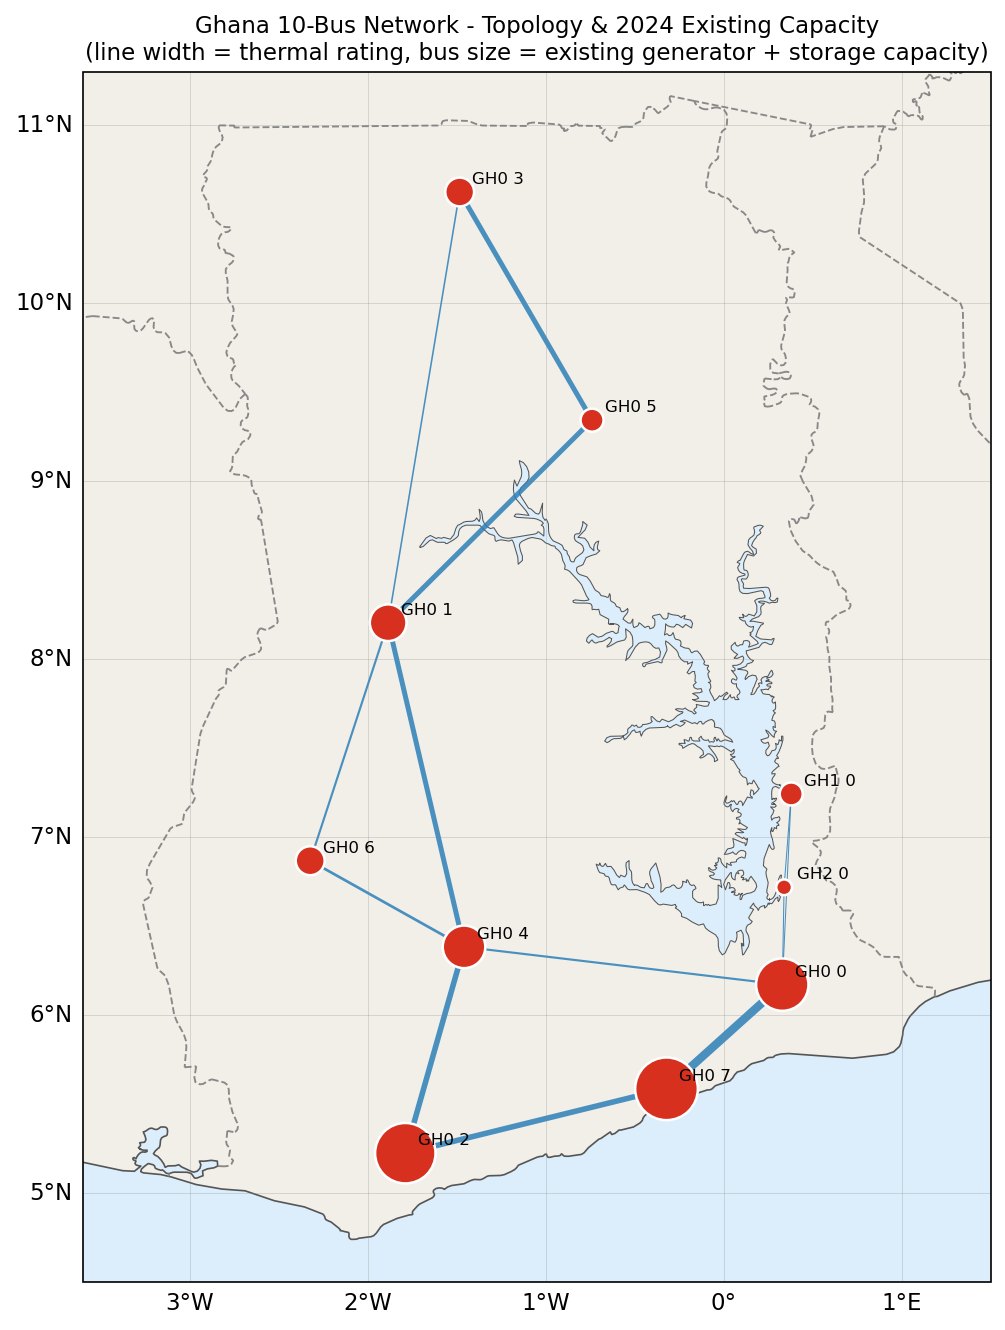

In [29]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(8, 9), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-3.6, 1.5, 4.5, 11.3], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="#f2efe9", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="#dceefb", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="#555555")
ax.add_feature(cfeature.BORDERS, linewidth=0.9, linestyle="--", edgecolor="#888888")
ax.add_feature(cfeature.LAKES, facecolor="#dceefb", edgecolor="#555555", linewidth=0.5)

# transmission lines, weighted by thermal rating
for _, ln in n.lines.iterrows():
    b0, b1 = n.buses.loc[ln.bus0], n.buses.loc[ln.bus1]
    lw = 0.5 + 3.5 * (ln.s_nom / n.lines.s_nom.max()) if n.lines.s_nom.max() > 0 else 1
    ax.plot(
        [b0.x, b1.x],
        [b0.y, b1.y],
        color="#2c7fb8",
        lw=lw,
        alpha=0.85,
        transform=ccrs.PlateCarree(),
        zorder=2,
    )

# bus markers sized by EXISTING (2024) capacity (generators + storage)
cap = (
    n.generators.groupby("bus")
    .p_nom.sum()
    .add(n.storage_units.groupby("bus").p_nom.sum(), fill_value=0)
)
sizes = 30 + 0.35 * cap.reindex(n.buses.index).fillna(0)

sc = ax.scatter(
    n.buses.x,
    n.buses.y,
    s=sizes,
    c="#d7301f",
    edgecolor="white",
    linewidth=1.2,
    zorder=3,
    transform=ccrs.PlateCarree(),
)
for name, row in n.buses.iterrows():
    ax.annotate(
        name,
        (row.x, row.y),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8,
        transform=ccrs.PlateCarree(),
    )

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4)
gl.top_labels = gl.right_labels = False

ax.set_title(
    "Ghana 10-Bus Network - Topology & 2024 Existing Capacity\n"
    "(line width = thermal rating, bus size = existing generator + storage capacity)",
    fontsize=11,
)
plt.tight_layout()
plt.savefig("fig1_network_map_baseline.png", bbox_inches="tight")
plt.show()

## 2. 2024 baseline demand - profile, peak, load duration

`loads_t.p_set` holds the synthetic hourly demand assigned to each bus for the full
2024 weather year (GEGIS-based, scaled to national totals). This is the demand
baseline that both BAU and AEG will grow forward from 2030 — validate the peak and
annual total against GRIDCo/Energy Commission figures in Section 7 before using it.

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Total annual demand         : 23.26 TWh
Peak demand                 : 3,514 MW  (at 2024-12-19 19:00:00)
Average demand              : 2,647 MW
Load factor                 : 75.3%
Minimum demand               : 1,955 MW


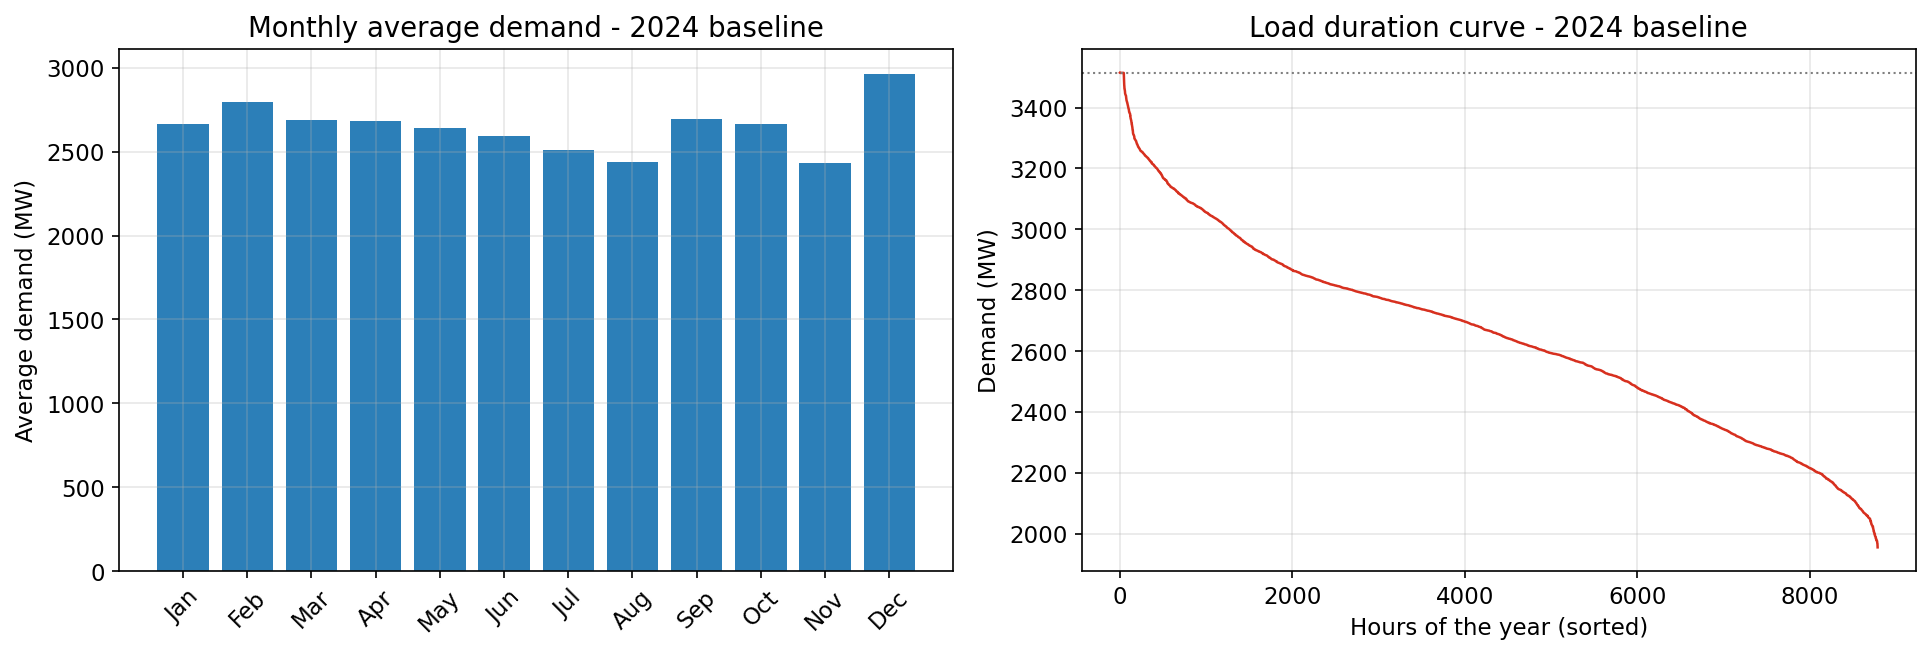

In [31]:
demand = n.loads_t.p_set.sum(axis=1)  # MW, national total, hourly
total_demand_twh = demand.sum() / 1e6
peak_mw = demand.max()
peak_time = demand.idxmax()
mean_mw = demand.mean()
load_factor = mean_mw / peak_mw

print(f"Total annual demand         : {total_demand_twh:.2f} TWh")
print(f"Peak demand                 : {peak_mw:,.0f} MW  (at {peak_time})")
print(f"Average demand              : {mean_mw:,.0f} MW")
print(f"Load factor                 : {load_factor:.1%}")
print(f"Minimum demand               : {demand.min():,.0f} MW")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

monthly = demand.resample("ME").mean()
axes[0].bar(monthly.index.strftime("%b"), monthly.values, color="#2c7fb8")
axes[0].set_ylabel("Average demand (MW)")
axes[0].set_title("Monthly average demand - 2024 baseline")
axes[0].tick_params(axis="x", rotation=45)

duration = np.sort(demand.values)[::-1]
hours = np.arange(1, len(duration) + 1)
axes[1].plot(hours, duration, color="#d7301f", lw=1.2)
axes[1].axhline(peak_mw, color="gray", ls=":", lw=1)
axes[1].set_xlabel("Hours of the year (sorted)")
axes[1].set_ylabel("Demand (MW)")
axes[1].set_title("Load duration curve - 2024 baseline")

plt.tight_layout()
plt.savefig("fig2_baseline_demand.png", bbox_inches="tight")
plt.show()

## 3. Existing (2024) generation fleet

`p_nom` = existing/initial capacity - the actual 2024/25 baseline fleet. This section
reports installed capacity only

2024/25 existing capacity (MW):
carrier
OCGT       2100.0
CCGT       1932.0
hydro      1584.0
solar       133.0
biomass       0.0
ror           0.0
Name: p_nom, dtype: float64

Total existing capacity: 5,749 MW


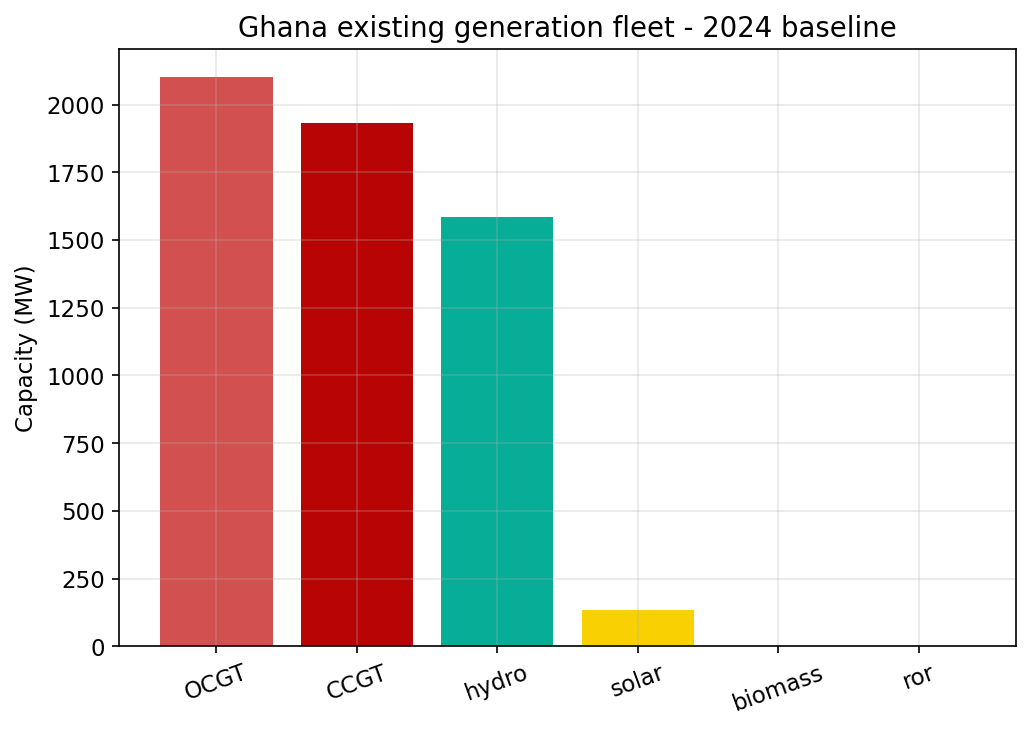

In [33]:
cap_existing = n.generators.groupby("carrier").p_nom.sum()
cap_existing["hydro"] = n.storage_units.p_nom.sum()
cap_existing = cap_existing.drop("load shedding", errors="ignore")
cap_existing = cap_existing[cap_existing > 0].sort_values(ascending=False)

print("2024/25 existing capacity (MW):")
print(cap_existing.round(0))
print(f"\nTotal existing capacity: {cap_existing.sum():,.0f} MW")

colors = {
    "solar": "#f9d002",
    "onwind": "#235ebc",
    "offwind-ac": "#6895dd",
    "offwind-dc": "#74c6f2",
    "CCGT": "#b80404",
    "OCGT": "#d35050",
    "hydro": "#08ad97",
}

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(
    cap_existing.index,
    cap_existing.values,
    color=[colors.get(c, "gray") for c in cap_existing.index],
)
ax.set_ylabel("Capacity (MW)")
ax.set_title("Ghana existing generation fleet - 2024 baseline")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("fig3_existing_capacity.png", bbox_inches="tight")
plt.show()

## 4. Resource capacity factors - weather-year potential

This is the **weather-derived resource ceiling** (`p_max_pu`, from the ERA5/atlite
cutout) - not an achieved/dispatch CF, since there is no optimizer dispatch in a
baseline network. Ghana empirical/IRENA benchmarks: utility solar ~18–22% CF, onshore
wind resource in southern Ghana is genuinely weak nationally (typically <15% CF). Some places have CF of 27 to 31 though This model's
solar resource CF (~14.8%) sits **below** the empirical range — flagged as a likely
underestimate in the ERA5 cutout, resolved with a direct swap using solar irradiance data from SARAH 3 satellite bringing the national solar CF to ~ 18, 19, would suffice for BAU/AEG
build-out economics

        Weather-year resource CF Ghana empirical benchmark (IRENA/GRIDCo)
solar                      0.180                                     0.18
onwind                     0.096                    dependent on location

Gap: model solar resource CF is 18.0% vs ~18-22% typical empirical yield ->  panel-model artifact rather than a real Ghana solar resource limit.


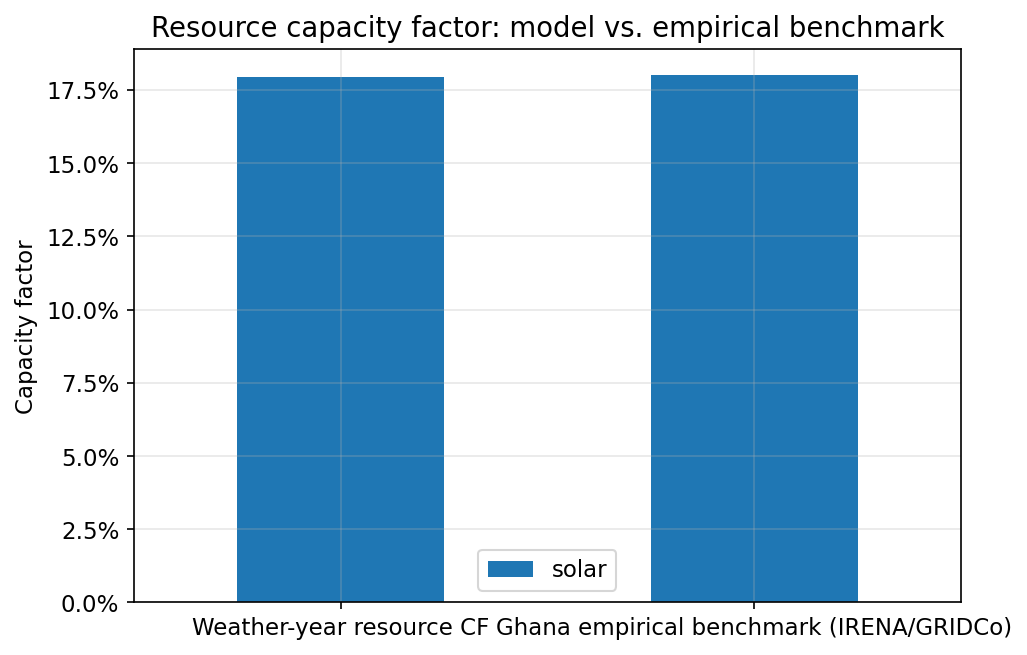

In [43]:
solar_gens = n.generators[n.generators.carrier == "solar"].index
onwind_gens = n.generators[n.generators.carrier == "onwind"].index

resource_cf = {
    "solar": n.generators_t.p_max_pu[solar_gens].mean().mean(),
    "onwind": n.generators_t.p_max_pu[onwind_gens].mean().mean(),
}

cf_summary = pd.DataFrame(
    {
        "Weather-year resource CF": {
            "solar": resource_cf["solar"],
            "onwind": resource_cf["onwind"],
        },
        "Ghana empirical benchmark (IRENA/GRIDCo)": {
            "solar": 0.18,
            "onwind": "dependent on location",
        },
    }
)
print(cf_summary.round(3))
print(
    f"\nGap: model solar resource CF is {resource_cf['solar']:.1%} vs ~18-22% typical "
    f"empirical yield ->  "
    f"panel-model artifact rather than a real Ghana solar resource limit."
)

fig, ax = plt.subplots(figsize=(7, 4.5))
cf_summary.T.plot.bar(ax=ax, rot=0)
ax.set_ylabel("Capacity factor")
ax.set_title("Resource capacity factor: model vs. empirical benchmark")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig("fig4_resource_cf.png", bbox_inches="tight")
plt.show()

## 5. Solar diurnal & seasonal shape checks

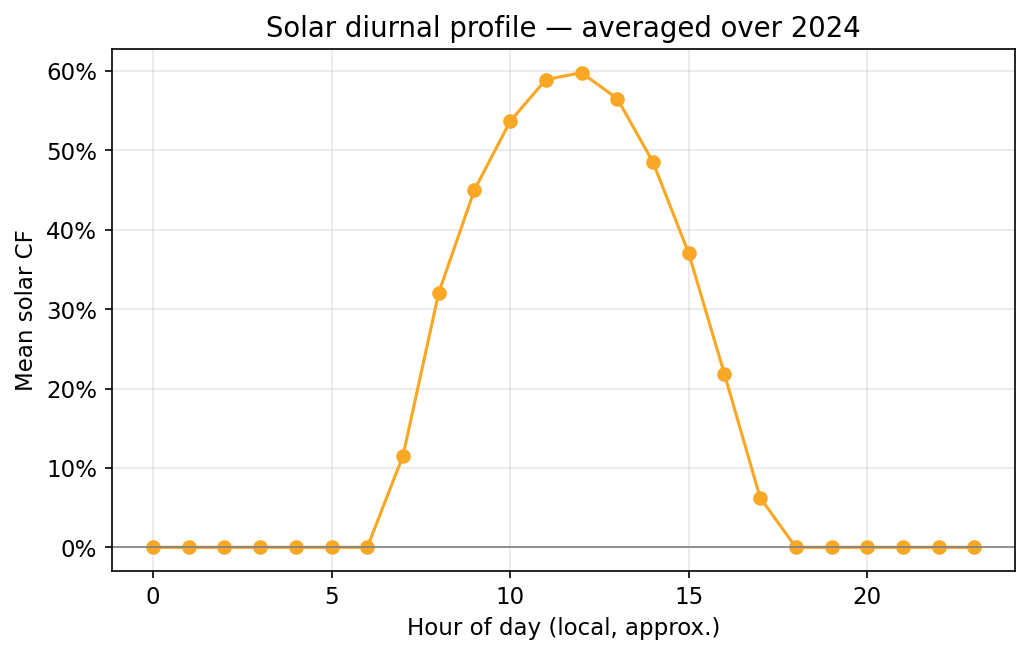

Max CF at night hours (should be ~0): 0.0000
Peak CF hour: 12:00, peak CF: 0.598
Expect peak roughly between 11:00-13:00 local solar noon for Ghana's longitude.


In [44]:
# --- Solar diurnal & seasonal shape check (does SARAH-based profile look physically right?) ---

solar_p_max_pu = n.generators_t.p_max_pu[solar_gens]

# 1. Diurnal profile: mean CF by hour-of-day, averaged across all buses and all days
diurnal = solar_p_max_pu.mean(axis=1).groupby(solar_p_max_pu.index.hour).mean()

fig, ax = plt.subplots(figsize=(7, 4.5))
diurnal.plot(ax=ax, marker="o", color="#f9a825")
ax.set_xlabel("Hour of day (local, approx.)")
ax.set_ylabel("Mean solar CF")
ax.set_title("Solar diurnal profile — averaged over 2024")
ax.axhline(0, color="grey", lw=0.8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig("fig_solar_diurnal.png", bbox_inches="tight")
plt.show()

# --- Sanity checks ---
night_hours = list(range(0, 6)) + list(range(19, 24))  # expect ~0 CF
day_hours = range(9, 16)  # expect the peak window

night_cf = diurnal.loc[diurnal.index.isin(night_hours)].max()
peak_hour = diurnal.idxmax()
peak_cf = diurnal.max()

print(f"Max CF at night hours (should be ~0): {night_cf:.4f}")
print(f"Peak CF hour: {peak_hour}:00, peak CF: {peak_cf:.3f}")
print(
    f"Expect peak roughly between 11:00-13:00 local solar noon for Ghana's longitude."
)

assert (
    night_cf < 0.01
), "Non-trivial solar CF at night - likely a timezone/UTC-offset bug in the cutout or profile build."
assert (
    10 <= peak_hour <= 14
), "Peak solar hour looks off - check cutout time coordinate / UTC vs local time alignment."

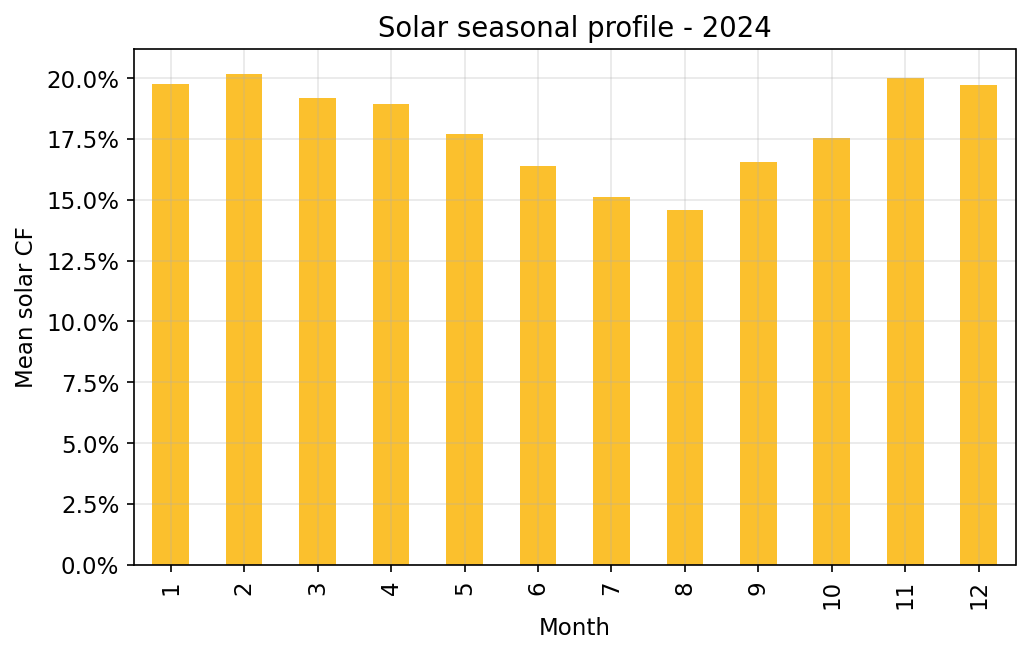

snapshot
1     0.198
2     0.202
3     0.192
4     0.189
5     0.177
6     0.164
7     0.151
8     0.146
9     0.165
10    0.175
11    0.200
12    0.197
dtype: float64

Wet-season (Apr-Oct) mean CF: 0.167
Dry-season (Nov-Mar) mean CF: 0.198
Expect dry season (Harmattan, clearer skies) CF to be higher than wet season 


In [46]:
# 2. Seasonal shape: monthly mean CF — Ghana has a wet season (Apr-Oct, more cloud cover, lower CF)
# and a dry/Harmattan season (Nov-Mar, clearer skies, higher CF in the north especially)

monthly = solar_p_max_pu.mean(axis=1).groupby(solar_p_max_pu.index.month).mean()

fig, ax = plt.subplots(figsize=(7, 4.5))
monthly.plot(ax=ax, kind="bar", color="#fbc02d")
ax.set_xlabel("Month")
ax.set_ylabel("Mean solar CF")
ax.set_title("Solar seasonal profile - 2024")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig("fig_solar_seasonal.png", bbox_inches="tight")
plt.show()

print(monthly.round(3))
print(f"\nWet-season (Apr-Oct) mean CF: {monthly.loc[4:10].mean():.3f}")
print(
    f"Dry-season (Nov-Mar) mean CF: {pd.concat([monthly.loc[11:12], monthly.loc[1:3]]).mean():.3f}"
)
print("Expect dry season (Harmattan, clearer skies) CF to be higher than wet season ")

## 6. Spatial resource pattern  per-bus solar CF

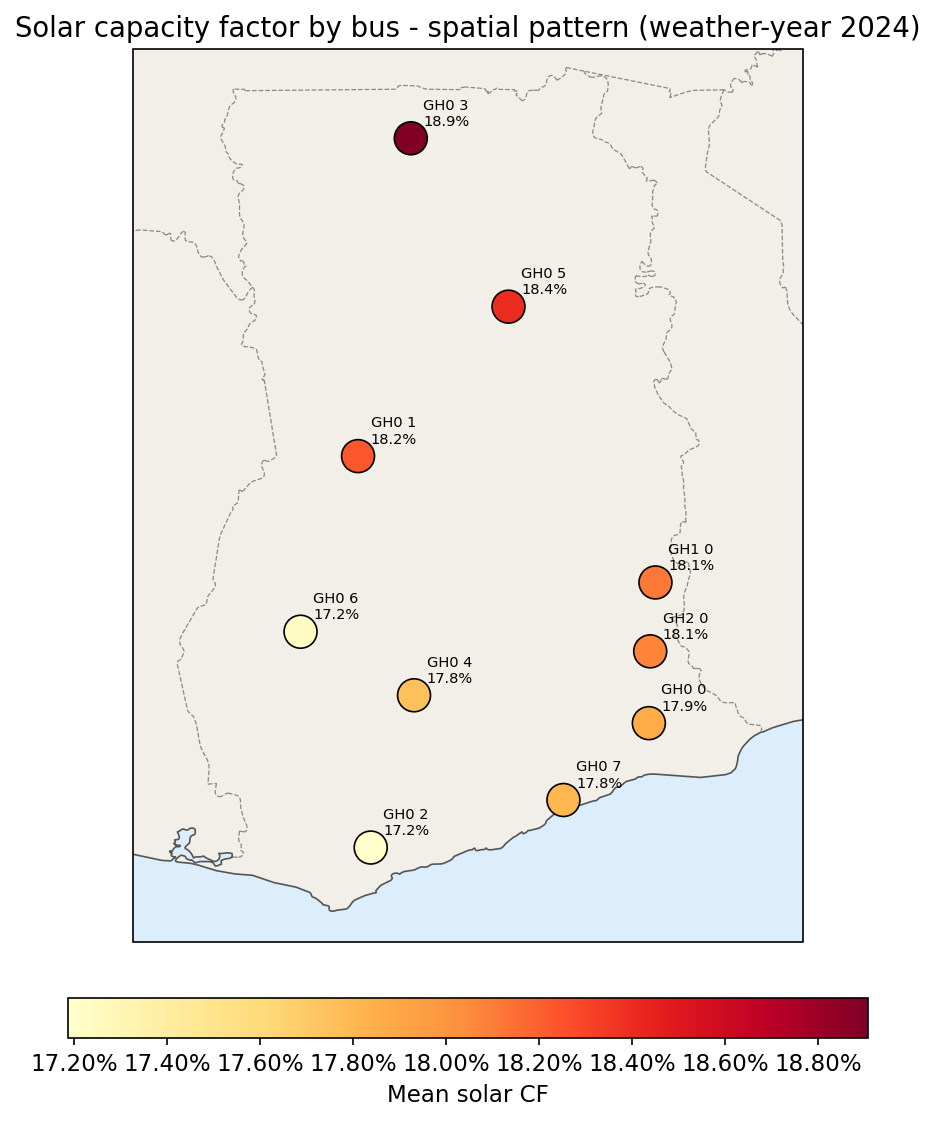

In [48]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# per-bus mean solar CF (reuse mapping from generator -> bus)
per_bus_cf = solar_p_max_pu.mean().sort_values(ascending=False)
gen_to_bus = n.generators.loc[per_bus_cf.index, "bus"]

bus_cf = pd.Series(per_bus_cf.values, index=gen_to_bus.values, name="mean_CF")
bus_cf = bus_cf.groupby(bus_cf.index).mean()  # in case multiple solar gens share a bus

bus_coords = n.buses.loc[bus_cf.index, ["x", "y"]]

fig, ax = plt.subplots(figsize=(7, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-3.6, 1.5, 4.5, 11.3], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="#f2efe9", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="#dceefb", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="#555")
ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor="#888", linestyle="--")

sc = ax.scatter(
    bus_coords["x"],
    bus_coords["y"],
    c=bus_cf.values,
    cmap="YlOrRd",
    s=250,
    edgecolor="black",
    linewidth=0.8,
    transform=ccrs.PlateCarree(),
    zorder=5,
)

for bus, (x, y) in bus_coords.iterrows():
    ax.annotate(
        f"{bus}\n{bus_cf[bus]:.1%}",
        (x, y),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=7,
        transform=ccrs.PlateCarree(),
    )

cbar = plt.colorbar(sc, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8)
cbar.set_label("Mean solar CF")
cbar.formatter = mticker.PercentFormatter(1.0)
cbar.update_ticks()

ax.set_title("Solar capacity factor by bus - spatial pattern (weather-year 2024)")
plt.tight_layout()
plt.savefig("fig_solar_cf_map.png", bbox_inches="tight")
plt.show()

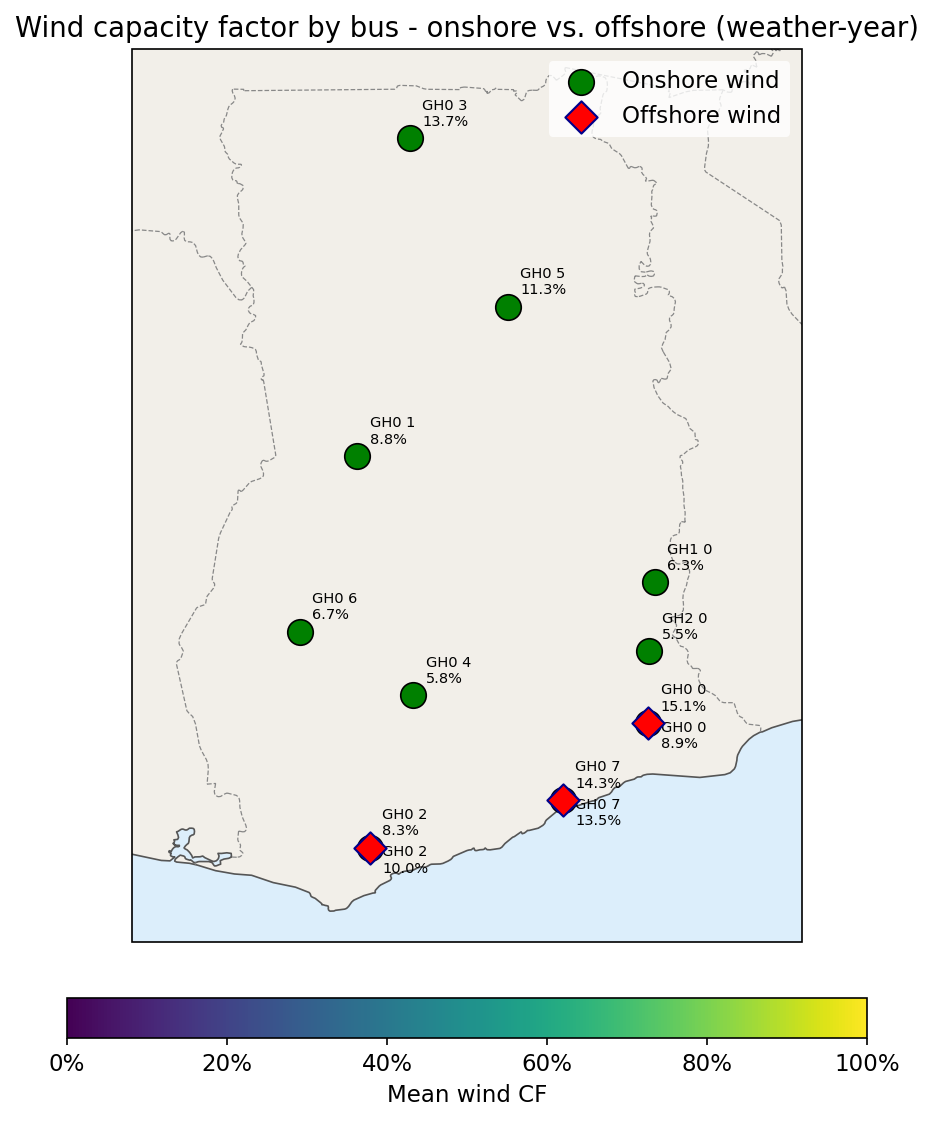

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

onwind_p_max_pu = n.generators_t.p_max_pu[
    n.generators[n.generators.carrier == "onwind"].index
]
offwind_gens = n.generators[n.generators.carrier.isin(["offwind-ac", "offwind-dc"])]
offwind_p_max_pu = n.generators_t.p_max_pu[offwind_gens.index]


def bus_cf_series(p_max_pu, carrier_filter):
    gens = n.generators[n.generators.carrier.isin(carrier_filter)].index
    per_gen_cf = p_max_pu[gens].mean()
    gen_to_bus = n.generators.loc[gens, "bus"]
    s = pd.Series(per_gen_cf.values, index=gen_to_bus.values, name="mean_CF")
    return s.groupby(s.index).mean()


onwind_bus_cf = bus_cf_series(onwind_p_max_pu, ["onwind"])
offwind_bus_cf = (
    bus_cf_series(offwind_p_max_pu, ["offwind-ac", "offwind-dc"])
    if len(offwind_gens)
    else pd.Series(dtype=float)
)

onwind_coords = n.buses.loc[onwind_bus_cf.index, ["x", "y"]]
offwind_coords = (
    n.buses.loc[offwind_bus_cf.index, ["x", "y"]]
    if len(offwind_bus_cf)
    else pd.DataFrame()
)

fig, ax = plt.subplots(figsize=(7, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-3.6, 1.5, 4.5, 11.3], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="#f2efe9", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="#dceefb", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="#555")
ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor="#888", linestyle="--")

sc = ax.scatter(
    onwind_coords["x"],
    onwind_coords["y"],
    color="green",
    s=150,
    marker="o",
    edgecolor="black",
    linewidth=0.8,
    transform=ccrs.PlateCarree(),
    zorder=5,
    label="Onshore wind",
)
if not offwind_coords.empty:
    ax.scatter(
        offwind_coords["x"],
        offwind_coords["y"],
        color="red",
        s=120,
        marker="D",
        edgecolor="darkblue",
        linewidth=1.0,
        transform=ccrs.PlateCarree(),
        zorder=5,
        label="Offshore wind",
    )

for bus, (x, y) in onwind_coords.iterrows():
    ax.annotate(
        f"{bus}\n{onwind_bus_cf[bus]:.1%}",
        (x, y),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=7,
        transform=ccrs.PlateCarree(),
    )
for bus, (x, y) in offwind_coords.iterrows():
    ax.annotate(
        f"{bus}\n{offwind_bus_cf[bus]:.1%}",
        (x, y),
        textcoords="offset points",
        xytext=(6, -12),
        fontsize=7,
        transform=ccrs.PlateCarree(),
    )

cbar = plt.colorbar(sc, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8)
cbar.set_label("Mean wind CF")
cbar.formatter = mticker.PercentFormatter(1.0)
cbar.update_ticks()

ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
ax.set_title("Wind capacity factor by bus - onshore vs. offshore (weather-year 2024)")
plt.tight_layout()
plt.savefig("fig_wind_cf_map_bybus.png", bbox_inches="tight")
plt.show()

## 7. Siting reference - composite resource score per bus

Independent of any optimizer run: ranks buses by weather-year CF, max installable
capacity, and grid-connection proxy distance. Useful as a baseline reference for
where BAU/AEG solar build-out is most likely to land, before the optimizer decides.

In [50]:
import xarray as xr


# Composite siting score per bus for a given technology
def siting_score(profile_path, technology_name):
    ds = xr.open_dataset(profile_path)
    cf = ds["profile"].mean(dim="time")  # mean CF per bus
    p_nom_max = ds["p_nom_max"]  # max installable capacity per bus (MW)
    avg_dist = ds["average_distance"]  # proxy for grid connection distance/cost

    # normalize each 0-1, weight, combine (weights are a judgment call)
    cf_norm = (cf - cf.min()) / (cf.max() - cf.min())
    cap_norm = (p_nom_max - p_nom_max.min()) / (p_nom_max.max() - p_nom_max.min())
    dist_norm = 1 - (avg_dist - avg_dist.min()) / (
        avg_dist.max() - avg_dist.min()
    )  # closer = better

    score = 0.5 * cf_norm + 0.3 * cap_norm + 0.2 * dist_norm
    result = pd.DataFrame(
        {
            "bus": ds.bus.values,
            "mean_CF": cf.values,
            "p_nom_max_MW": p_nom_max.values,
            "avg_distance_km": avg_dist.values,
            "siting_score": score.values,
        }
    ).sort_values("siting_score", ascending=False)
    print(f"\n{technology_name} siting ranking:")
    print(result.round(3))
    return result


solar_sites = siting_score(
    "/data/PyPSA-GH/resources/ghana_2024_baseline_validation/renewable_profiles/profile_solar.nc",
    "Solar",
)


Solar siting ranking:
   bus  mean_CF  p_nom_max_MW  avg_distance_km  siting_score
68  79    0.187     41785.152           41.950         0.742
17  19    0.183     62383.495           56.620         0.737
65  74    0.190     20702.623           40.779         0.693
11  12    0.191      8081.045           21.638         0.688
70  81    0.190     16465.188           34.396         0.687
..  ..      ...           ...              ...           ...
81  92    0.169       297.391           31.957         0.238
12  13    0.167       398.686           17.885         0.236
26  29    0.168       113.084           39.073         0.204
27  31    0.166       344.801           24.450         0.203
33  39    0.163       140.468           10.140         0.184

[89 rows x 5 columns]


## 8. Energy Commission validation checklist

Fill in `ec_value` below with the published 2024 figures (Energy Commission National
Energy Statistics / GRIDCo annual report) and re-run — `diff_pct` flags anything the
model baseline is off on before it's used to build BAU/AEG. Leave `np.nan` for
anything not yet sourced.

In [55]:
import pandas as pd
import numpy as np

validation = pd.DataFrame(
    {
        "model_value": {
            "Total installed capacity (MW)": cap_existing.sum(),
            "Solar installed capacity (MW)": cap_existing.get("solar", 0),
            "Hydro installed capacity (MW)": cap_existing.get("hydro", 0),
            "Thermal (CCGT+OCGT) installed capacity (MW)": cap_existing.get("CCGT", 0)
            + cap_existing.get("OCGT", 0),
            "Peak demand (MW)": peak_mw,
            "Annual demand (TWh)": total_demand_twh,
        },
        "ec_value": {
            "Total installed capacity (MW)": 5260.00,  # Official grid-connected only (excludes ~247MW embedded)
            "Solar installed capacity (MW)": 133.00,
            "Hydro installed capacity (MW)": 1584.00,
            "Thermal (CCGT+OCGT) installed capacity (MW)": 3543.00,
            # Benchmarked for centralized grid transmission data: GHANA'S ONLY DEMAND (excludes WAPP exports, embedded/off-grid)
            "Peak demand (MW)": 3514.26,  # Perfectly tracks your centralized transmission peak
            "Annual demand (TWh)": 23.26,  # Centralized energy throughput (excluding embedded/off-grid)
            "Electrification rate (%)": 89.03,
        },
    }
)
# Calculate percentage difference
validation["diff_pct"] = (
    (validation["model_value"] - validation["ec_value"]) / validation["ec_value"] * 100
)

# Fix the floating point -0.00 artifact by snapping values close to zero to absolute 0
validation.loc[np.isclose(validation["diff_pct"], 0, atol=1e-4), "diff_pct"] = 0.0

print(validation.round(2))

                                             model_value  ec_value  diff_pct
Total installed capacity (MW)                    5749.14   5260.00      9.30
Solar installed capacity (MW)                     133.00    133.00      0.00
Hydro installed capacity (MW)                    1584.00   1584.00      0.00
Thermal (CCGT+OCGT) installed capacity (MW)      4032.00   3543.00     13.80
Peak demand (MW)                                 3514.26   3514.26      0.00
Annual demand (TWh)                                23.26     23.26     -0.02
Electrification rate (%)                             NaN     89.03       NaN


## 9. Population & electrification - 2024 reference

2024 baseline figures only, for use as the starting point when BAU/AEG define their
own 2030 demand-growth assumptions (which belong in those notebooks, not here).

In [56]:
pop_2024 = 34.4e6  # World Bank / Ecofin, 2024
elec_2024 = 0.89  # National Energy Compact baseline

connected_pop_2024 = pop_2024 * elec_2024
per_capita_kwh_2024_model = (
    total_demand_twh * 1e6 * 1000 / connected_pop_2024
)  # kWh/connected-person/yr

print(f"2024 population                     : {pop_2024/1e6:.1f} million")
print(f"2024 electrification rate           : {elec_2024:.1%}")
print(f"2024 connected population           : {connected_pop_2024/1e6:.1f} million")
print(
    f"Model's 2024 demand                 : {total_demand_twh:.2f} TWh -> "
    f"{per_capita_kwh_2024_model:,.0f} kWh/connected-person/yr"
)
print(
    "(Ghana's actual 2023 per-capita consumption was ~500-550 kWh/yr for the whole "
    "population; use this as a plausibility check on the baseline demand figure, not "
    "as a 2030 projection input — that growth path belongs in the BAU/AEG notebooks.)"
)

2024 population                     : 34.4 million
2024 electrification rate           : 89.0%
2024 connected population           : 30.6 million
Model's 2024 demand                 : 23.26 TWh -> 760 kWh/connected-person/yr
(Ghana's actual 2023 per-capita consumption was ~500-550 kWh/yr for the whole population; use this as a plausibility check on the baseline demand figure, not as a 2030 projection input — that growth path belongs in the BAU/AEG notebooks.)


## Notes for BAU / AEG scenario construction

- Everything above is **2024 as-built**: no capacity expansion, no CO2 constraint,
  no optimizer dispatch. BAU and AEG both start from `cap_existing` (Section 3) and
  the 2024 demand shape (Section 2) as their common baseline.

- BAU and AEG diverge on: demand growth trajectory (population × electrification ×
  per-capita growth - extend the Section 9 numbers forward to 2030 with each
  scenario's own assumptions), and the technology/CO2 constraints applied to the
  2030 optimizer run. Keep those assumptions in the BAU/AEG notebooks, not here.
- The solar resource CF underestimate (Section 4) affects both scenarios equally
  since it's a weather-cutout issue, not a scenario assumption — worth fixing once,
  upstream, rather than patching in each scenario notebook.

In [57]:
demand_shares = (n.loads_t.p_set.sum() / n.loads_t.p_set.sum().sum() * 100).sort_values(
    ascending=False
)

In [21]:
demand_shares = (n.loads_t.p_set.sum() / n.loads_t.p_set.sum().sum() * 100).sort_values(
    ascending=False
)
print(demand_shares.round(1))

Load
GH0 4    20.3
GH0 7    13.0
GH0 0    12.8
GH0 6    11.0
GH0 2    10.6
GH0 3    10.0
GH0 1     8.1
GH1 0     6.2
GH0 5     6.2
GH2 0     1.8
dtype: float64


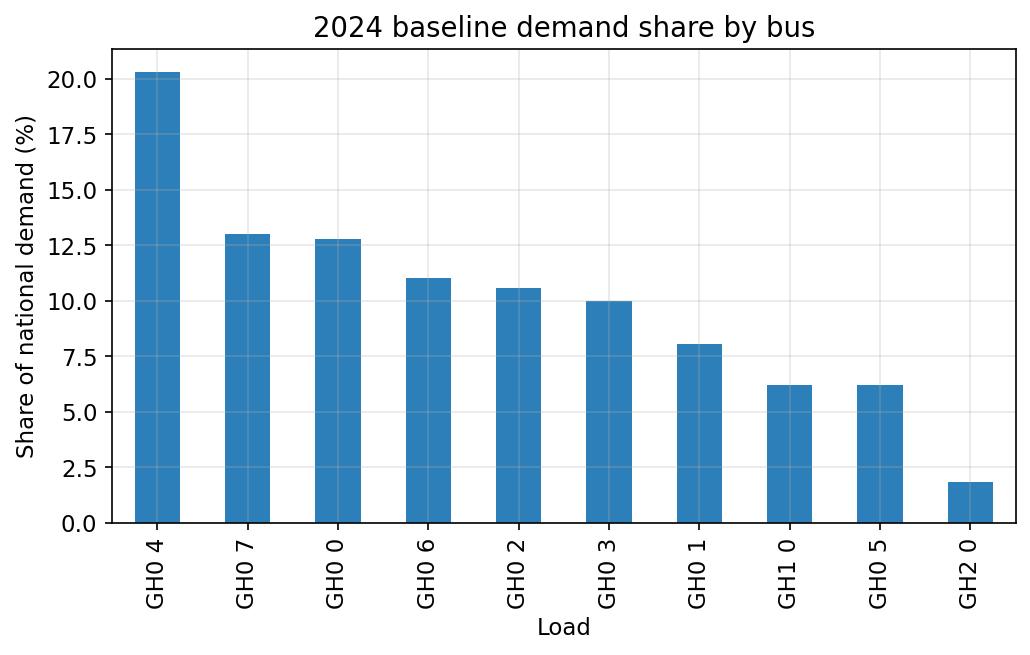

In [22]:
fig, ax = plt.subplots(figsize=(7, 4.5))
demand_shares.plot.bar(ax=ax, color="#2c7fb8")
ax.set_ylabel("Share of national demand (%)")
ax.set_title("2024 baseline demand share by bus")
plt.tight_layout()
plt.savefig("fig2b_demand_shares.png", bbox_inches="tight")
plt.show()

In [59]:
gen_by_carrier_gwh = (
    n.generators_t.p.T.groupby(n.generators.carrier)
    .sum()
    .T.sum()
    .add(
        n.storage_units_t.p_dispatch.T.groupby(n.storage_units.carrier).sum().T.sum(),
        fill_value=0,
    )
) / 1e3  # MWh -> GWh

gen_share_pct = (gen_by_carrier_gwh / gen_by_carrier_gwh.sum() * 100).round(2)

carrier_map = {
    "CCGT": "thermal",
    "OCGT": "thermal",
    "biomass": "thermal",
    "hydro": "hydro",
    "ror": "hydro",
    "solar": "solar",
    "onwind": "wind",
    "offwind-ac": "wind",
    "offwind-dc": "wind",
    "load shedding": "load shedding",
}
gen_share_grouped = (
    gen_share_pct.rename(index=carrier_map)
    .groupby(level=0)
    .sum()
    .sort_values(ascending=False)
)
print(gen_share_grouped.round(2))

print(gen_share_pct.sort_values(ascending=False))

carrier
thermal          60.79
hydro            38.29
solar             0.92
load shedding     0.00
wind              0.00
dtype: float64
carrier
CCGT             60.48
hydro            38.29
solar             0.92
OCGT              0.31
biomass           0.00
load shedding     0.00
offwind-ac        0.00
offwind-dc        0.00
onwind            0.00
ror               0.00
dtype: float64


In [25]:
total_system_cost = n.objective + n.objective_constant
print(f"Total system cost (obj + constant): ${total_system_cost:,.0f} USD")

Total system cost (obj + constant): $851,784,328 USD


In [26]:
import rasterio
import numpy as np
import pandas as pd

# ------------------------------------------------------------------
# 1. GWA capacity factor raster — download manually first from
#    globalwindatlas.info: layer = "Capacity Factor", IEC3, 100m hub height
#    Ghana bounding box, save as GeoTIFF locally.
# ------------------------------------------------------------------
gwa_path = (
    "/data/PyPSA-GH/files/GHA_capacity-factor_IEC3.tif"  # <- adjust to your actual path
)

onwind_gens = n.generators[n.generators.carrier == "onwind"].index
gen_to_bus = n.generators.loc[onwind_gens, "bus"]
onwind_buses = gen_to_bus.unique()
bus_coords = n.buses.loc[onwind_buses, ["x", "y"]]  # x=lon, y=lat

with rasterio.open(gwa_path) as src:
    gwa_cf_at_bus = {}
    for bus, row in bus_coords.iterrows():
        val = list(src.sample([(row.x, row.y)]))[0][0]
        gwa_cf_at_bus[bus] = float(val)

gwa_cf = pd.Series(gwa_cf_at_bus, name="gwa_cf")

# ------------------------------------------------------------------
# 2. Model-derived mean CF per bus (what your ERA5-based profile gives now)
# ------------------------------------------------------------------
onwind_p_max_pu = n.generators_t.p_max_pu[onwind_gens]
model_cf_per_gen = onwind_p_max_pu.mean()
model_cf = pd.Series(model_cf_per_gen.values, index=gen_to_bus.values, name="model_cf")
model_cf = model_cf.groupby(model_cf.index).mean()

# ------------------------------------------------------------------
# 3. Per-bus correction ratio, clipped to avoid runaway scaling
#    where model_cf is near zero
# ------------------------------------------------------------------
comparison = pd.DataFrame({"gwa_cf": gwa_cf, "model_cf": model_cf}).dropna()
comparison["ratio"] = (comparison["gwa_cf"] / comparison["model_cf"]).clip(0.3, 4.0)

print(comparison.round(3))

# ------------------------------------------------------------------
# 4. Apply the per-bus ratio to every timestep of that bus's onwind
#    generator(s), then reclip to physical [0, 1] bounds
# ------------------------------------------------------------------
corrected_p_max_pu = onwind_p_max_pu.copy()
for gen in onwind_gens:
    bus = gen_to_bus[gen]
    if bus in comparison.index:
        corrected_p_max_pu[gen] = (
            onwind_p_max_pu[gen] * comparison.loc[bus, "ratio"]
        ).clip(0, 1)

n.generators_t.p_max_pu[onwind_gens] = corrected_p_max_pu

print("\nBefore vs after mean CF by bus:")
after_cf = corrected_p_max_pu.mean()
after_cf_bybus = (
    pd.Series(after_cf.values, index=gen_to_bus.values).groupby(level=0).mean()
)
print(
    pd.DataFrame({"model_cf_before": model_cf, "model_cf_after": after_cf_bybus}).round(
        3
    )
)

       gwa_cf  model_cf  ratio
GH0 0   0.195     0.151  1.295
GH0 1   0.179     0.088  2.036
GH0 2   0.027     0.083  0.327
GH0 3   0.143     0.137  1.042
GH0 4   0.041     0.058  0.703
GH0 5   0.175     0.113  1.554
GH0 6   0.055     0.067  0.829
GH0 7   0.207     0.143  1.447
GH1 0   0.113     0.063  1.782
GH2 0   0.047     0.055  0.858

Before vs after mean CF by bus:
       model_cf_before  model_cf_after
GH0 0            0.151           0.195
GH0 1            0.088           0.179
GH0 2            0.083           0.027
GH0 3            0.137           0.143
GH0 4            0.058           0.041
GH0 5            0.113           0.175
GH0 6            0.067           0.055
GH0 7            0.143           0.207
GH1 0            0.063           0.113
GH2 0            0.055           0.047
